This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes for hidden channels, kernels, and modes are:
    - [8], [4, 4], [3, 3] 
    - [16, 16], [8, 8, 8], [3, 3, 3] 
    - [32, 32, 32], [16, 16, 16, 16], [3, 3, 3, 3] 
    - [64, 64, 64, 64], [32, 32, 32, 32, 32], [3, 3, 3, 3, 3] 
    - [128, 128, 128, 128, 128], [64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3] 
    - [256, 256, 256, 256, 256, 256], [64, 64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3, 3] 
2. P, Q, final projection networks as follows:
    - For P:
        - in_ch=1
        - out_ch=128
        - hidden_ch=[8, 32]
    - For Q:
        - in_ch=128
        - out_ch=32
        - hidden_ch=[32, 8]
    - For final projection:
        - Linear[32, 64]
        - GELU
        - Linear[64, 3]
3. Of varying learning rates fine tuned for the given model. With a Cosine annealing lr scheduler with warmup in first 10 epochs.
4. With dropout, optimized using AdamW.
5. A loss of simple MSE, with a small additional terms for sum of residuals.
6. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
7. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
8. Trained using a GPU.
9. Standard Normed Variate datasets.
10. GELU as the activation function throughout.

### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.fno.FNO import FNO_nD
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [7]:
# Define model configs

cfg_p = {
    'in_channels': 1, 
    'out_channels': 128, 
    'hidden_channels': [8, 32], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}

cfg_q = {
    'in_channels': 128, 
    'out_channels': 32, 
    'hidden_channels': [128, 64], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}



models_list = [
    {
        'fb_hidden_channels': [8], 'fb_modes': [[4], [4]], 'fb_kernel': [3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [16,16], 'fb_modes': [[8], [8], [8]], 'fb_kernel': [3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [32,32,32], 'fb_modes': [[16], [16], [16], [16]], 'fb_kernel': [3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [64,64,64,64], 'fb_modes': [[32], [32], [32], [32], [32]], 'fb_kernel': [3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [128,128,128,128,128], 'fb_modes': [[40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [256,256,256,256,256,256], 'fb_modes': [[40], [40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3,3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    }
]

lr_list = [1e-3, 2.5e-3, 5e-3, 8e-4, 3e-4, 3e-4]

dir_list = [
    'fno_8',
    'fno_16',
    'fno_32',
    'fno_64',
    'fno_128',
    'fno_256'
]

name_list = [
        'FNO_8',
        'FNO_16',
        'FNO_32',
        'FNO_64',
        'FNO_128',
        'FNO_256'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'fno' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.104222
Epoch 1/80, Step 2/47, Train Loss: 0.103793
Epoch 1/80, Step 3/47, Train Loss: 0.111109
Epoch 1/80, Step 4/47, Train Loss: 0.083049
Epoch 1/80, Step 5/47, Train Loss: 0.101806
Epoch 1/80, Step 6/47, Train Loss: 0.116202
Epoch 1/80, Step 7/47, Train Loss: 0.095911
Epoch 1/80, Step 8/47, Train Loss: 0.110587
Epoch 1/80, Step 9/47, Train Loss: 0.093334
Epoch 1/80, Step 10/47, Train Loss: 0.094566
Epoch 1/80, Step 11/47, Train Loss: 0.095757
Epoch 1/80, Step 12/47, Train Loss: 0.105705
Epoch 1/80, Step 13/47, Train Loss: 0.107753
Epoch 1/80, Step 14/47, Train Loss: 0.115632
Epoch 1/80, Step 15/47, Train Loss: 0.101131
Epoch 1/80, Step 16/47, Train Loss: 0.084513
Epoch 1/80, Step 17/47, Train Loss: 0.099544
Epoch 1/80, Step 18/47, Train Loss: 0.087677
Epoch 1/80, Step 19/47, Train Loss: 0.086827
Epoch 1/80, Step 20/47, Train Loss: 0.088451
Epoch 1/80, Step 21/47, Train Loss: 0.090628
Epoch 1/80, Step 22/47, Train Loss: 0.091897
Epoch 1/80, Step 23

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 7/47, Train Loss: 0.024439
Epoch 11/80, Step 8/47, Train Loss: 0.039180
Epoch 11/80, Step 9/47, Train Loss: 0.030047
Epoch 11/80, Step 10/47, Train Loss: 0.047791
Epoch 11/80, Step 11/47, Train Loss: 0.038634
Epoch 11/80, Step 12/47, Train Loss: 0.032717
Epoch 11/80, Step 13/47, Train Loss: 0.058125
Epoch 11/80, Step 14/47, Train Loss: 0.022898
Epoch 11/80, Step 15/47, Train Loss: 0.035032
Epoch 11/80, Step 16/47, Train Loss: 0.042848
Epoch 11/80, Step 17/47, Train Loss: 0.030255
Epoch 11/80, Step 18/47, Train Loss: 0.047072
Epoch 11/80, Step 19/47, Train Loss: 0.029046
Epoch 11/80, Step 20/47, Train Loss: 0.055213
Epoch 11/80, Step 21/47, Train Loss: 0.027506
Epoch 11/80, Step 22/47, Train Loss: 0.033973
Epoch 11/80, Step 23/47, Train Loss: 0.027848
Epoch 11/80, Step 24/47, Train Loss: 0.026436
Epoch 11/80, Step 25/47, Train Loss: 0.033857
Epoch 11/80, Step 26/47, Train Loss: 0.033479
Epoch 11/80, Step 27/47, Train Loss: 0.021222
Epoch 11/80, Step 28/47, Train Loss: 

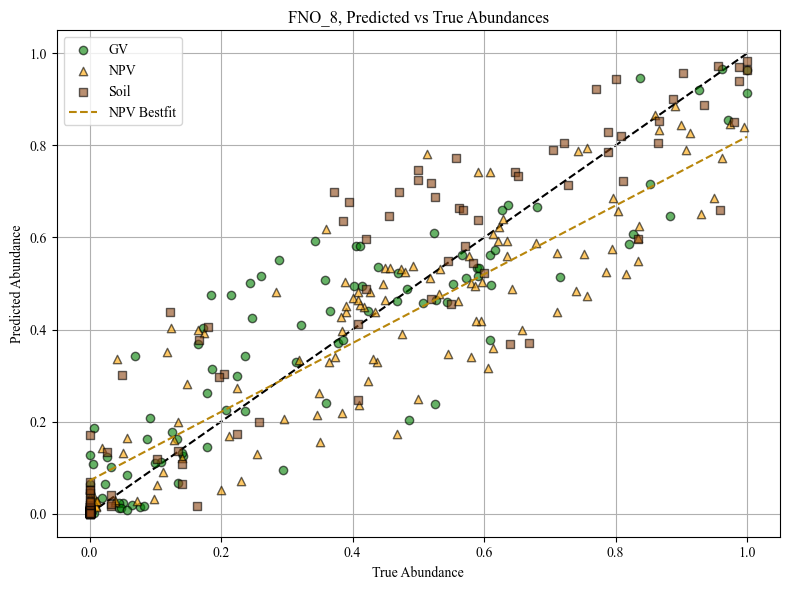

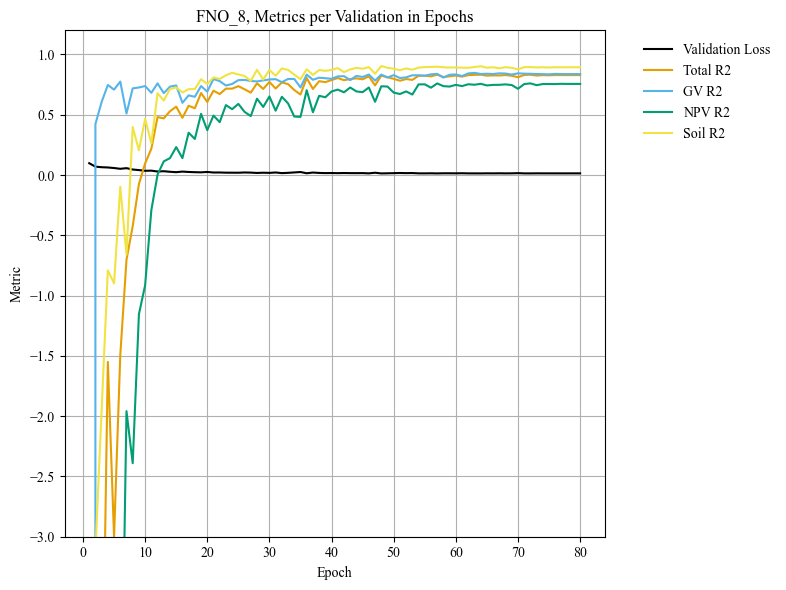

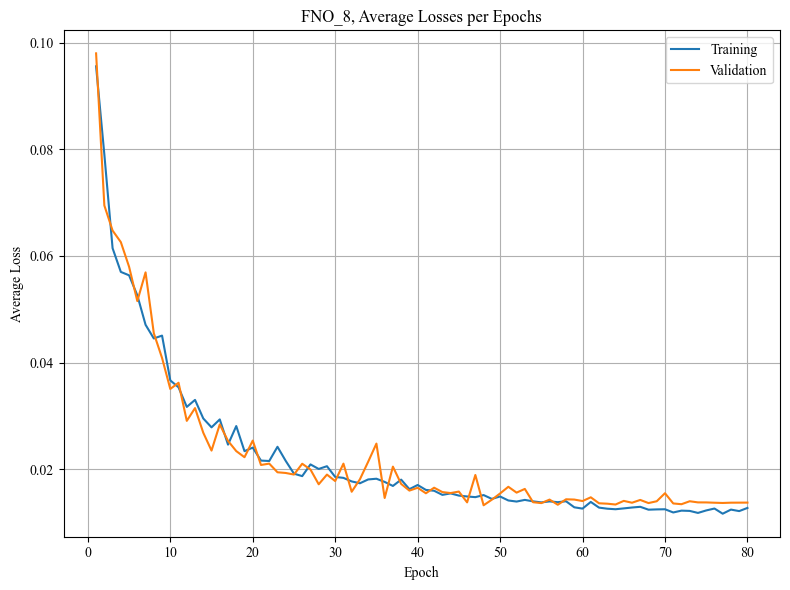

Testing complete
[[1.16539000e+05 1.68157440e+07 1.46719152e-02 7.96008825e-01
  8.32681715e-01 6.52381182e-01 9.02963698e-01 8.25483799e-02
  7.38681331e-02 1.08805805e-01 6.49712086e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101112
Epoch 1/80, Step 2/47, Train Loss: 0.098233
Epoch 1/80, Step 3/47, Train Loss: 0.101965
Epoch 1/80, Step 4/47, Train Loss: 0.098829
Epoch 1/80, Step 5/47, Train Loss: 0.093265
Epoch 1/80, Step 6/47, Train Loss: 0.107659
Epoch 1/80, Step 7/47, Train Loss: 0.099746
Epoch 1/80, Step 8/47, Train Loss: 0.093850
Epoch 1/80, Step 9/47, Train Loss: 0.092726
Epoch 1/80, Step 10/47, Train Loss: 0.119496
Epoch 1/80, Step 11/47, Train Loss: 0.104302
Epoch 1/80, Step 12/47, Train Loss: 0.111961
Epoch 1/80, Step 13/47, Train Loss: 0.101972
Epoch 1/80, Step 14/47, Train Loss: 0.095080
Epoch 1/80, Step 15/47, Train Loss: 0.095023
Epoch 1/80, Step 16/47, Train Loss: 0.095255
Epoch 1/80, Step 17/47, Train Loss: 0.097228
Epoch 1/80, Step 18/47, Train Loss: 0.084406
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 3/47, Train Loss: 0.032634
Epoch 11/80, Step 4/47, Train Loss: 0.012218
Epoch 11/80, Step 5/47, Train Loss: 0.016516
Epoch 11/80, Step 6/47, Train Loss: 0.035352
Epoch 11/80, Step 7/47, Train Loss: 0.026651
Epoch 11/80, Step 8/47, Train Loss: 0.034808
Epoch 11/80, Step 9/47, Train Loss: 0.033543
Epoch 11/80, Step 10/47, Train Loss: 0.019275
Epoch 11/80, Step 11/47, Train Loss: 0.019147
Epoch 11/80, Step 12/47, Train Loss: 0.017824
Epoch 11/80, Step 13/47, Train Loss: 0.011074
Epoch 11/80, Step 14/47, Train Loss: 0.015153
Epoch 11/80, Step 15/47, Train Loss: 0.019189
Epoch 11/80, Step 16/47, Train Loss: 0.012450
Epoch 11/80, Step 17/47, Train Loss: 0.026303
Epoch 11/80, Step 18/47, Train Loss: 0.032739
Epoch 11/80, Step 19/47, Train Loss: 0.022773
Epoch 11/80, Step 20/47, Train Loss: 0.023267
Epoch 11/80, Step 21/47, Train Loss: 0.020736
Epoch 11/80, Step 22/47, Train Loss: 0.018885
Epoch 11/80, Step 23/47, Train Loss: 0.023161
Epoch 11/80, Step 24/47, Train Loss: 0.02

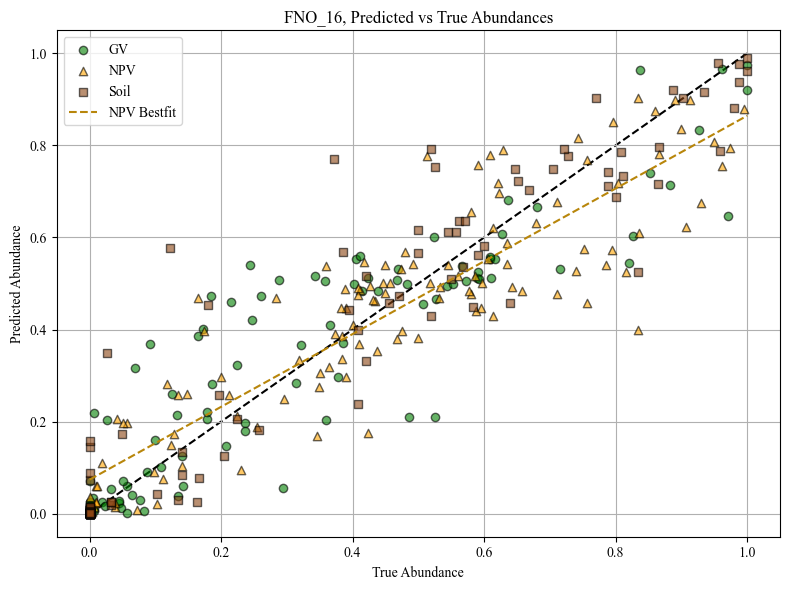

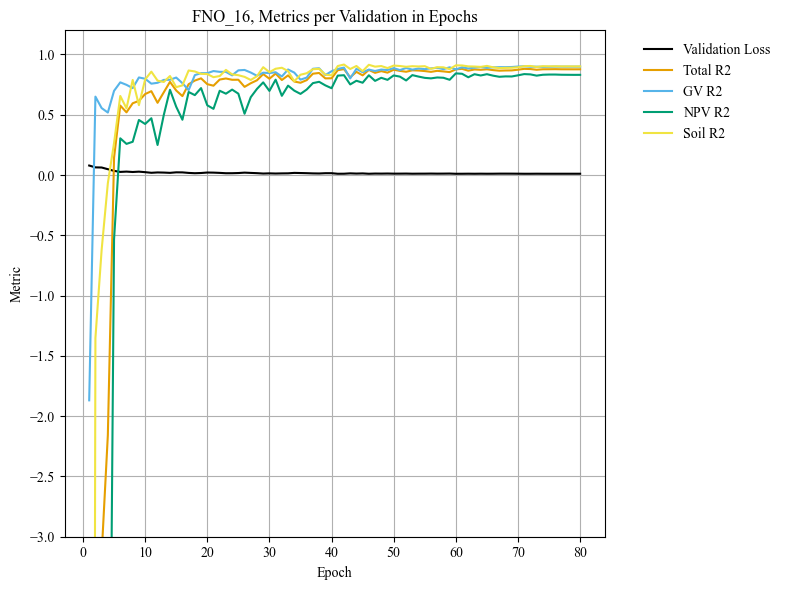

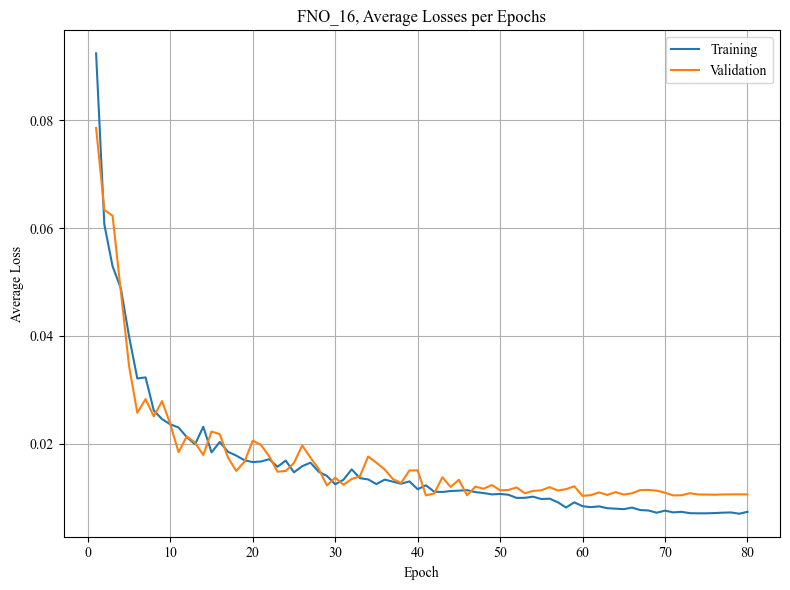

Testing complete
[[1.54019000e+05 1.85893120e+07 1.27869276e-02 8.27112198e-01
  8.22845697e-01 7.44345307e-01 9.14145648e-01 7.50086233e-02
  7.46156201e-02 9.51452181e-02 5.52650429e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101189
Epoch 1/80, Step 2/47, Train Loss: 0.097364
Epoch 1/80, Step 3/47, Train Loss: 0.100126
Epoch 1/80, Step 4/47, Train Loss: 0.074749
Epoch 1/80, Step 5/47, Train Loss: 0.085106
Epoch 1/80, Step 6/47, Train Loss: 0.088969
Epoch 1/80, Step 7/47, Train Loss: 0.099989
Epoch 1/80, Step 8/47, Train Loss: 0.098765
Epoch 1/80, Step 9/47, Train Loss: 0.090381
Epoch 1/80, Step 10/47, Train Loss: 0.097943
Epoch 1/80, Step 11/47, Train Loss: 0.088421
Epoch 1/80, Step 12/47, Train Loss: 0.115575
Epoch 1/80, Step 13/47, Train Loss: 0.084889
Epoch 1/80, Step 14/47, Train Loss: 0.102776
Epoch 1/80, Step 15/47, Train Loss: 0.085917
Epoch 1/80, Step 16/47, Train Loss: 0.085574
Epoch 1/80, Step 17/47, Train Loss: 0.095337
Epoch 1/80, Step 18/47, Train Loss: 0.079966
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 4/47, Train Loss: 0.019879
Epoch 11/80, Step 5/47, Train Loss: 0.013908
Epoch 11/80, Step 6/47, Train Loss: 0.029368
Epoch 11/80, Step 7/47, Train Loss: 0.025053
Epoch 11/80, Step 8/47, Train Loss: 0.019680
Epoch 11/80, Step 9/47, Train Loss: 0.023511
Epoch 11/80, Step 10/47, Train Loss: 0.020942
Epoch 11/80, Step 11/47, Train Loss: 0.024519
Epoch 11/80, Step 12/47, Train Loss: 0.029563
Epoch 11/80, Step 13/47, Train Loss: 0.015501
Epoch 11/80, Step 14/47, Train Loss: 0.044894
Epoch 11/80, Step 15/47, Train Loss: 0.023166
Epoch 11/80, Step 16/47, Train Loss: 0.029693
Epoch 11/80, Step 17/47, Train Loss: 0.026373
Epoch 11/80, Step 18/47, Train Loss: 0.032416
Epoch 11/80, Step 19/47, Train Loss: 0.021074
Epoch 11/80, Step 20/47, Train Loss: 0.026747
Epoch 11/80, Step 21/47, Train Loss: 0.016600
Epoch 11/80, Step 22/47, Train Loss: 0.019478
Epoch 11/80, Step 23/47, Train Loss: 0.019388
Epoch 11/80, Step 24/47, Train Loss: 0.012175
Epoch 11/80, Step 25/47, Train Loss: 0.0

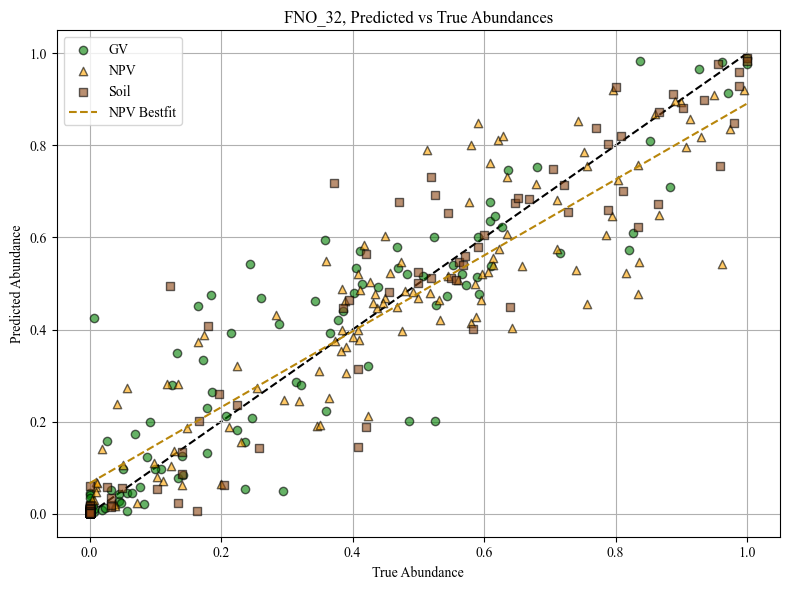

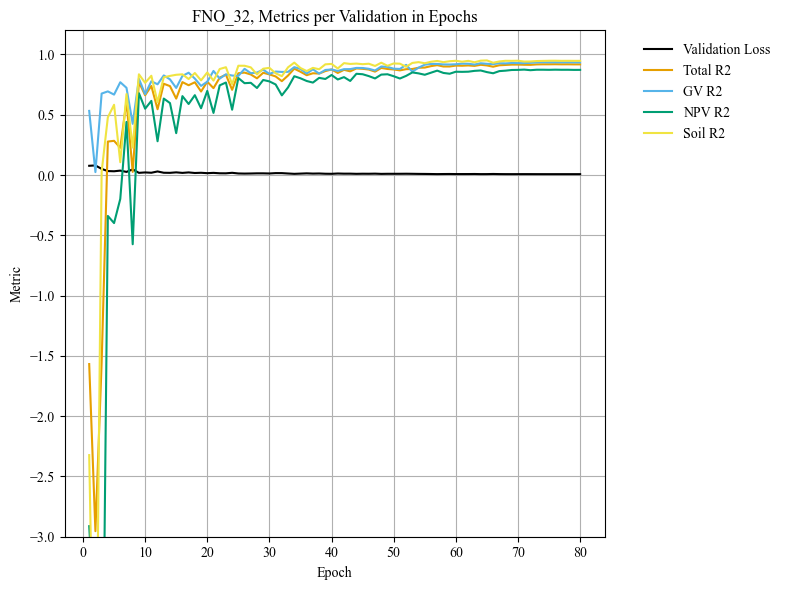

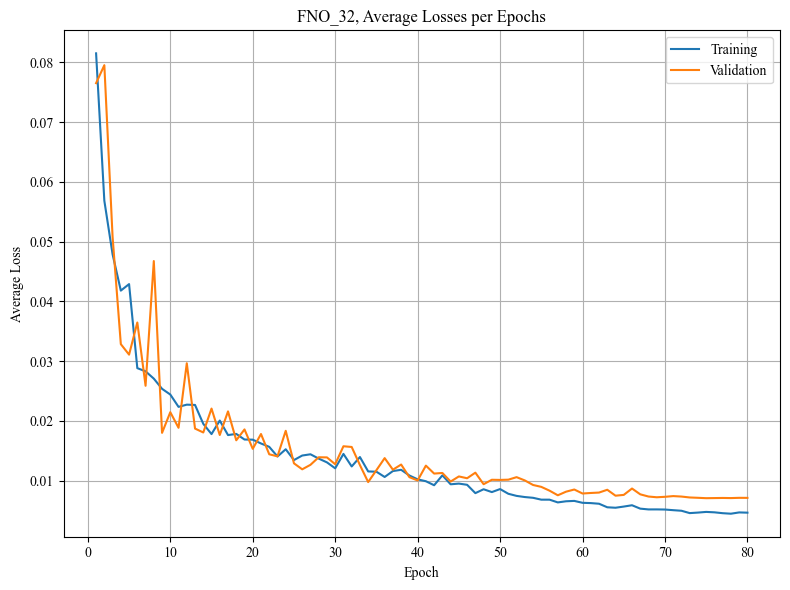

Testing complete
[[3.15315000e+05 2.39673600e+07 1.17091434e-02 8.51272523e-01
  8.55371475e-01 7.67092764e-01 9.31353271e-01 6.97651356e-02
  6.90998212e-02 9.30168703e-02 4.71787155e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.084442
Epoch 1/80, Step 2/47, Train Loss: 0.104289
Epoch 1/80, Step 3/47, Train Loss: 0.093169
Epoch 1/80, Step 4/47, Train Loss: 0.101935
Epoch 1/80, Step 5/47, Train Loss: 0.100977
Epoch 1/80, Step 6/47, Train Loss: 0.108154
Epoch 1/80, Step 7/47, Train Loss: 0.103314
Epoch 1/80, Step 8/47, Train Loss: 0.103284
Epoch 1/80, Step 9/47, Train Loss: 0.098384
Epoch 1/80, Step 10/47, Train Loss: 0.094904
Epoch 1/80, Step 11/47, Train Loss: 0.099071
Epoch 1/80, Step 12/47, Train Loss: 0.072476
Epoch 1/80, Step 13/47, Train Loss: 0.107362
Epoch 1/80, Step 14/47, Train Loss: 0.097750
Epoch 1/80, Step 15/47, Train Loss: 0.090608
Epoch 1/80, Step 16/47, Train Loss: 0.111538
Epoch 1/80, Step 17/47, Train Loss: 0.103558
Epoch 1/80, Step 18/47, Train Loss: 0.098241
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.022478
Epoch 11/80, Step 2/47, Train Loss: 0.009201
Epoch 11/80, Step 3/47, Train Loss: 0.026270
Epoch 11/80, Step 4/47, Train Loss: 0.021709
Epoch 11/80, Step 5/47, Train Loss: 0.012166
Epoch 11/80, Step 6/47, Train Loss: 0.012162
Epoch 11/80, Step 7/47, Train Loss: 0.017876
Epoch 11/80, Step 8/47, Train Loss: 0.026851
Epoch 11/80, Step 9/47, Train Loss: 0.019664
Epoch 11/80, Step 10/47, Train Loss: 0.012018
Epoch 11/80, Step 11/47, Train Loss: 0.018284
Epoch 11/80, Step 12/47, Train Loss: 0.028509
Epoch 11/80, Step 13/47, Train Loss: 0.009475
Epoch 11/80, Step 14/47, Train Loss: 0.020468
Epoch 11/80, Step 15/47, Train Loss: 0.021539
Epoch 11/80, Step 16/47, Train Loss: 0.021080
Epoch 11/80, Step 17/47, Train Loss: 0.018963
Epoch 11/80, Step 18/47, Train Loss: 0.029921
Epoch 11/80, Step 19/47, Train Loss: 0.025292
Epoch 11/80, Step 20/47, Train Loss: 0.016669
Epoch 11/80, Step 21/47, Train Loss: 0.010660
Epoch 11/80, Step 22/47, Train Loss: 0.0273

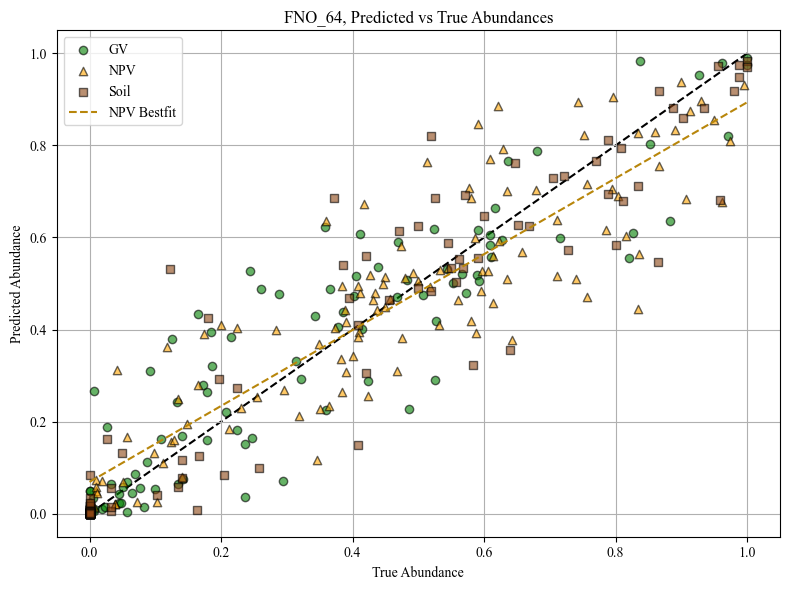

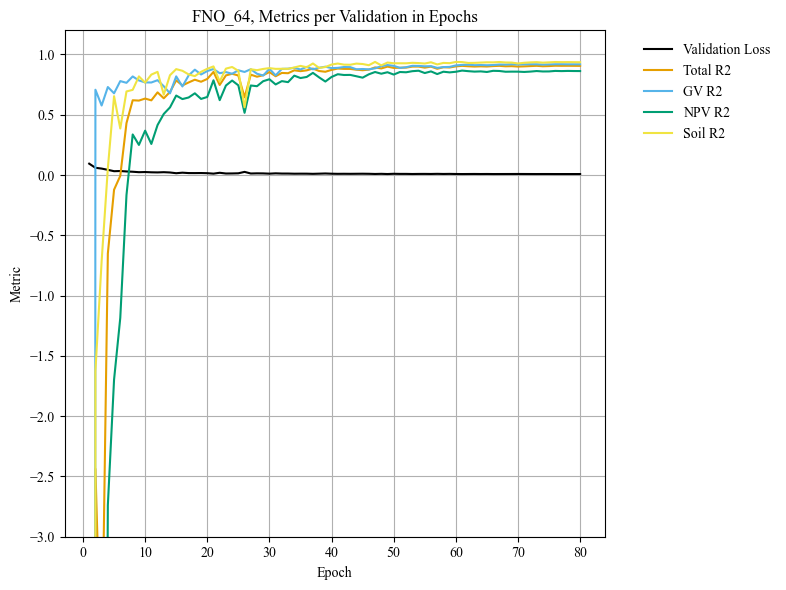

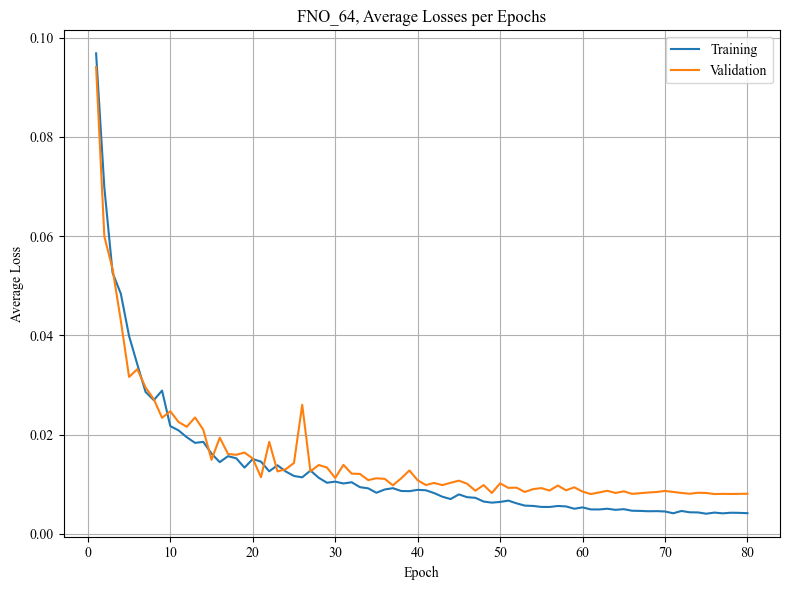

Testing complete
[[1.18638700e+06 4.41524480e+07 1.24049457e-02 8.43606770e-01
  8.58393192e-01 7.62111187e-01 9.10316050e-01 7.31200054e-02
  6.97056055e-02 9.49866772e-02 5.46677299e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.101196
Epoch 1/80, Step 2/47, Train Loss: 0.089116
Epoch 1/80, Step 3/47, Train Loss: 0.087419
Epoch 1/80, Step 4/47, Train Loss: 0.105037
Epoch 1/80, Step 5/47, Train Loss: 0.091853
Epoch 1/80, Step 6/47, Train Loss: 0.123124
Epoch 1/80, Step 7/47, Train Loss: 0.084901
Epoch 1/80, Step 8/47, Train Loss: 0.098175
Epoch 1/80, Step 9/47, Train Loss: 0.096412
Epoch 1/80, Step 10/47, Train Loss: 0.098719
Epoch 1/80, Step 11/47, Train Loss: 0.096399
Epoch 1/80, Step 12/47, Train Loss: 0.091294
Epoch 1/80, Step 13/47, Train Loss: 0.095267
Epoch 1/80, Step 14/47, Train Loss: 0.100590
Epoch 1/80, Step 15/47, Train Loss: 0.084935
Epoch 1/80, Step 16/47, Train Loss: 0.091081
Epoch 1/80, Step 17/47, Train Loss: 0.104369
Epoch 1/80, Step 18/47, Train Loss: 0.090005
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 10/80, Step 47/47, Train Loss: 0.022395
Epoch 10/80 complete. Train Loss: 0.022211, Val Loss: 0.017813
Epoch 11/80, Step 1/47, Train Loss: 0.012718
Epoch 11/80, Step 2/47, Train Loss: 0.015768
Epoch 11/80, Step 3/47, Train Loss: 0.015543
Epoch 11/80, Step 4/47, Train Loss: 0.031690
Epoch 11/80, Step 5/47, Train Loss: 0.036797
Epoch 11/80, Step 6/47, Train Loss: 0.020832
Epoch 11/80, Step 7/47, Train Loss: 0.022933
Epoch 11/80, Step 8/47, Train Loss: 0.015606
Epoch 11/80, Step 9/47, Train Loss: 0.022995
Epoch 11/80, Step 10/47, Train Loss: 0.018980
Epoch 11/80, Step 11/47, Train Loss: 0.030060
Epoch 11/80, Step 12/47, Train Loss: 0.022759
Epoch 11/80, Step 13/47, Train Loss: 0.020522
Epoch 11/80, Step 14/47, Train Loss: 0.016519
Epoch 11/80, Step 15/47, Train Loss: 0.026385
Epoch 11/80, Step 16/47, Train Loss: 0.013392
Epoch 11/80, Step 17/47, Train Loss: 0.027900
Epoch 11/80, Step 18/47, Train Loss: 0.023161
Epoch 11/80, Step 19/47, Train Loss: 0.021505
Epoch 11/80, Step 20/47, T

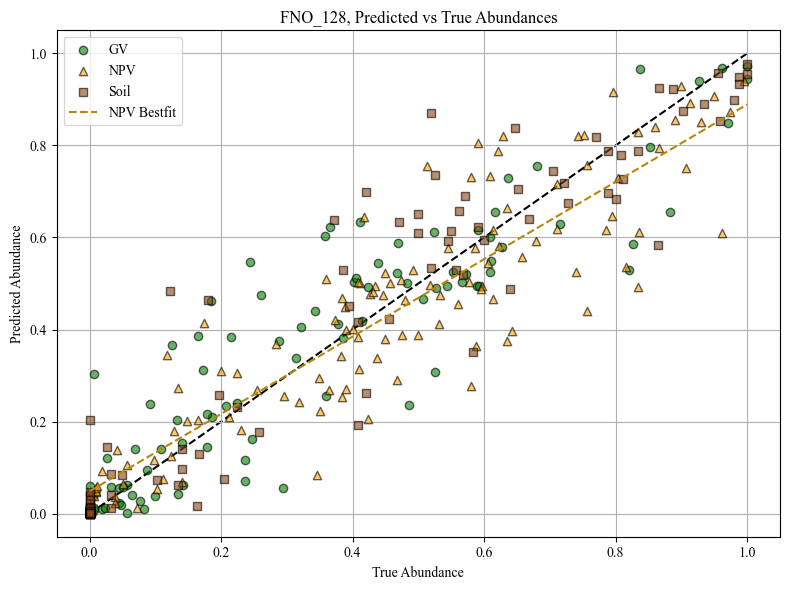

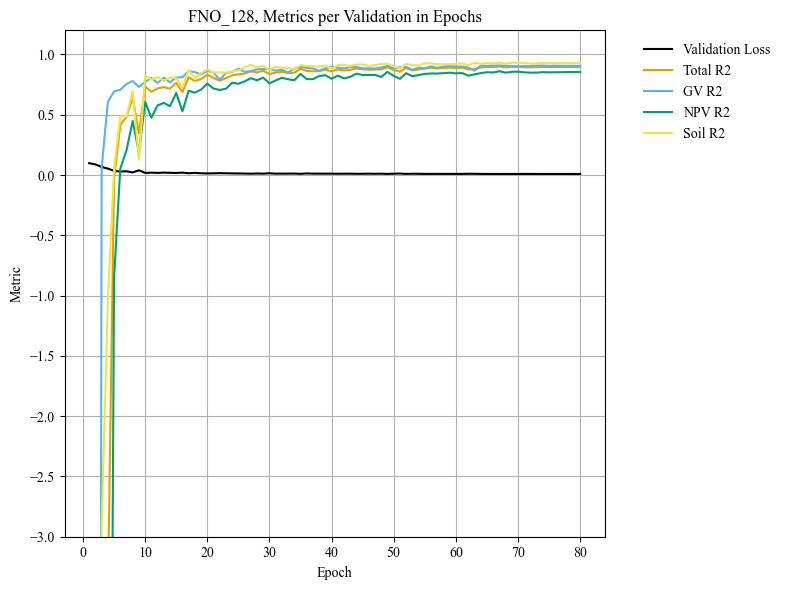

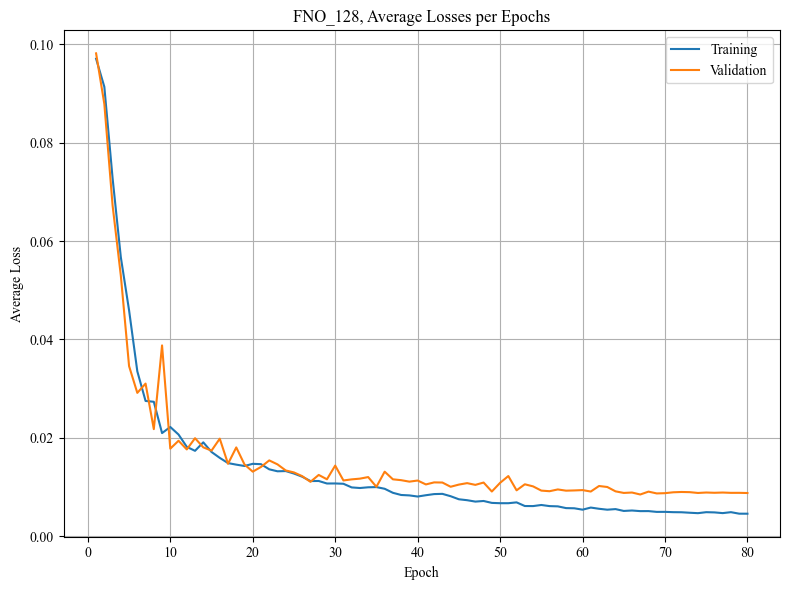

Testing complete
[[4.65704300e+06 1.22926720e+08 1.15939686e-02 8.56124222e-01
  8.62190843e-01 7.82839835e-01 9.23341930e-01 7.08227828e-02
  6.79056793e-02 9.10900012e-02 5.34726568e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.089151
Epoch 1/80, Step 2/47, Train Loss: 0.110482
Epoch 1/80, Step 3/47, Train Loss: 0.091004
Epoch 1/80, Step 4/47, Train Loss: 0.095190
Epoch 1/80, Step 5/47, Train Loss: 0.117973
Epoch 1/80, Step 6/47, Train Loss: 0.096658
Epoch 1/80, Step 7/47, Train Loss: 0.106457
Epoch 1/80, Step 8/47, Train Loss: 0.102920
Epoch 1/80, Step 9/47, Train Loss: 0.124841
Epoch 1/80, Step 10/47, Train Loss: 0.102928
Epoch 1/80, Step 11/47, Train Loss: 0.101798
Epoch 1/80, Step 12/47, Train Loss: 0.101183
Epoch 1/80, Step 13/47, Train Loss: 0.116603
Epoch 1/80, Step 14/47, Train Loss: 0.100482
Epoch 1/80, Step 15/47, Train Loss: 0.104743
Epoch 1/80, Step 16/47, Train Loss: 0.095855
Epoch 1/80, Step 17/47, Train Loss: 0.091626
Epoch 1/80, Step 18/47, Train Loss: 0.085676
Epoch 1/8

c:\Users\Ege\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.025208
Epoch 11/80, Step 2/47, Train Loss: 0.019923
Epoch 11/80, Step 3/47, Train Loss: 0.020315
Epoch 11/80, Step 4/47, Train Loss: 0.017255
Epoch 11/80, Step 5/47, Train Loss: 0.025880
Epoch 11/80, Step 6/47, Train Loss: 0.019681
Epoch 11/80, Step 7/47, Train Loss: 0.018730
Epoch 11/80, Step 8/47, Train Loss: 0.018869
Epoch 11/80, Step 9/47, Train Loss: 0.032446
Epoch 11/80, Step 10/47, Train Loss: 0.017921
Epoch 11/80, Step 11/47, Train Loss: 0.026305
Epoch 11/80, Step 12/47, Train Loss: 0.022311
Epoch 11/80, Step 13/47, Train Loss: 0.013058
Epoch 11/80, Step 14/47, Train Loss: 0.023894
Epoch 11/80, Step 15/47, Train Loss: 0.024999
Epoch 11/80, Step 16/47, Train Loss: 0.024998
Epoch 11/80, Step 17/47, Train Loss: 0.017116
Epoch 11/80, Step 18/47, Train Loss: 0.024231
Epoch 11/80, Step 19/47, Train Loss: 0.014924
Epoch 11/80, Step 20/47, Train Loss: 0.012851
Epoch 11/80, Step 21/47, Train Loss: 0.013531
Epoch 11/80, Step 22/47, Train Loss: 0.0205

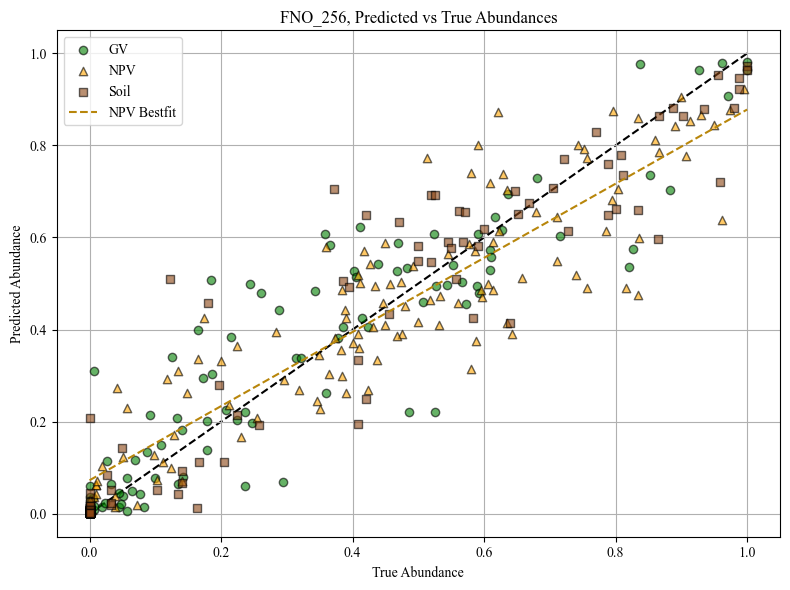

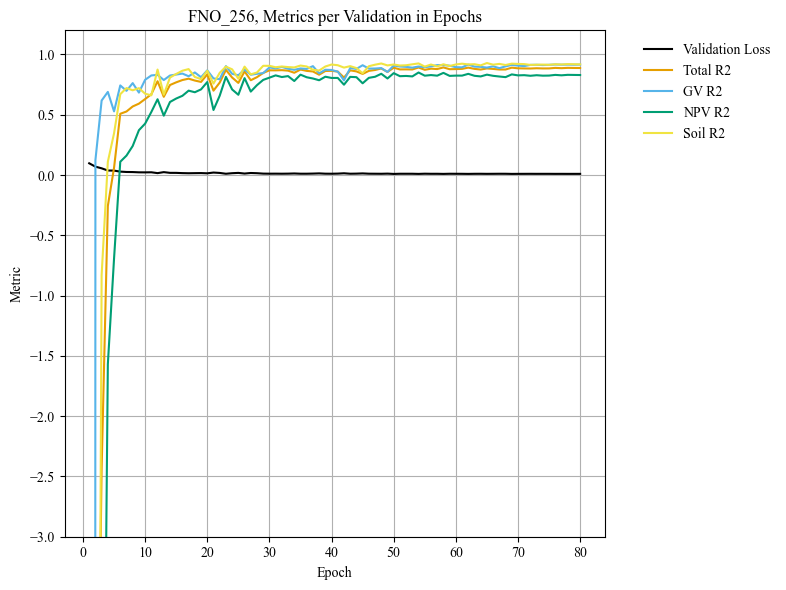

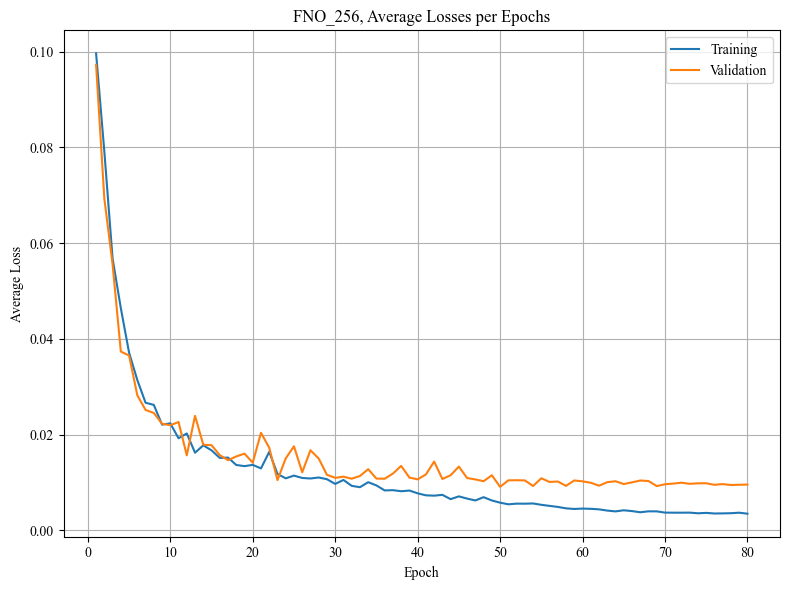

Testing complete
[[1.86529470e+07 4.97792640e+08 1.15476288e-02 8.48032415e-01
  8.59217048e-01 7.62980759e-01 9.21899319e-01 7.13705420e-02
  6.77440092e-02 9.34587047e-02 5.29089086e-02]]


In [8]:
fno_dict = {}
import gc


for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'fno' / dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32, SNV=True)
    model = FNO_nD(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    warmup_epochs = 10 
    total_steps = epoch * n_tb_epoch
    warmup_steps = warmup_epochs * n_tb_epoch
    # warmup
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, 
        start_factor=0.1, 
        total_iters=warmup_steps
    )
    # cosine annealing
    main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=total_steps - warmup_steps, 
        eta_min=1e-6
    )
    # combination
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, main_scheduler],
        milestones=[warmup_steps]
    )

    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name,
        fine_tuning=False
    )

    # After training a model and saving it to the dict/disk
    del model 
    gc.collect()
    torch.cuda.empty_cache()

    fno_dict[model_name] = model_dict
    print(fno_dict[model_name]['metrics_total'])

In [9]:
import pickle
with open('fno_dict.pkl', 'wb') as fp:
    pickle.dump(fno_dict, fp)

In [10]:
# Best models
best_models = [64,128,256]

for i in best_models:
    key = f'FNO_{i}'
    print(f'{key}, {fno_dict[key]["metrics_total"]}')


FNO_64, [[1.18638700e+06 4.41524480e+07 1.24049457e-02 8.43606770e-01
  8.58393192e-01 7.62111187e-01 9.10316050e-01 7.31200054e-02
  6.97056055e-02 9.49866772e-02 5.46677299e-02]]
FNO_128, [[4.65704300e+06 1.22926720e+08 1.15939686e-02 8.56124222e-01
  8.62190843e-01 7.82839835e-01 9.23341930e-01 7.08227828e-02
  6.79056793e-02 9.10900012e-02 5.34726568e-02]]
FNO_256, [[1.86529470e+07 4.97792640e+08 1.15476288e-02 8.48032415e-01
  8.59217048e-01 7.62980759e-01 9.21899319e-01 7.13705420e-02
  6.77440092e-02 9.34587047e-02 5.29089086e-02]]


In [11]:
for i in fno_dict.keys():
    print(f"For {i}, NPV R2: {fno_dict[i]['metrics_total'][0][5]}, param#: {fno_dict[i]['metrics_total'][0][0]}")

For FNO_8, NPV R2: 0.652381181716919, param#: 116539.0
For FNO_16, NPV R2: 0.7443453073501587, param#: 154019.0
For FNO_32, NPV R2: 0.767092764377594, param#: 315315.0
For FNO_64, NPV R2: 0.7621111869812012, param#: 1186387.0
For FNO_128, NPV R2: 0.782839834690094, param#: 4657043.0
For FNO_256, NPV R2: 0.7629807591438293, param#: 18652947.0
